In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Create graph
G = nx.Graph()

# Add buses (nodes)
G.add_nodes_from(range(1, 21))  # 20-node system

# Add feeder lines (radial + branches)
G.add_edges_from([
    # Main feeder
    (1,2), (2,3), (3,4), (4,5), (5,6), (6,7), (7,8), (8,9), (9,10),

    # Branches from main feeder
    (3,11), (11,12),
    (4,13),
    (5,14), (14,15),
    (6,16),
    (7,17), (17,18),
    (8,19),
    (9,20)
])


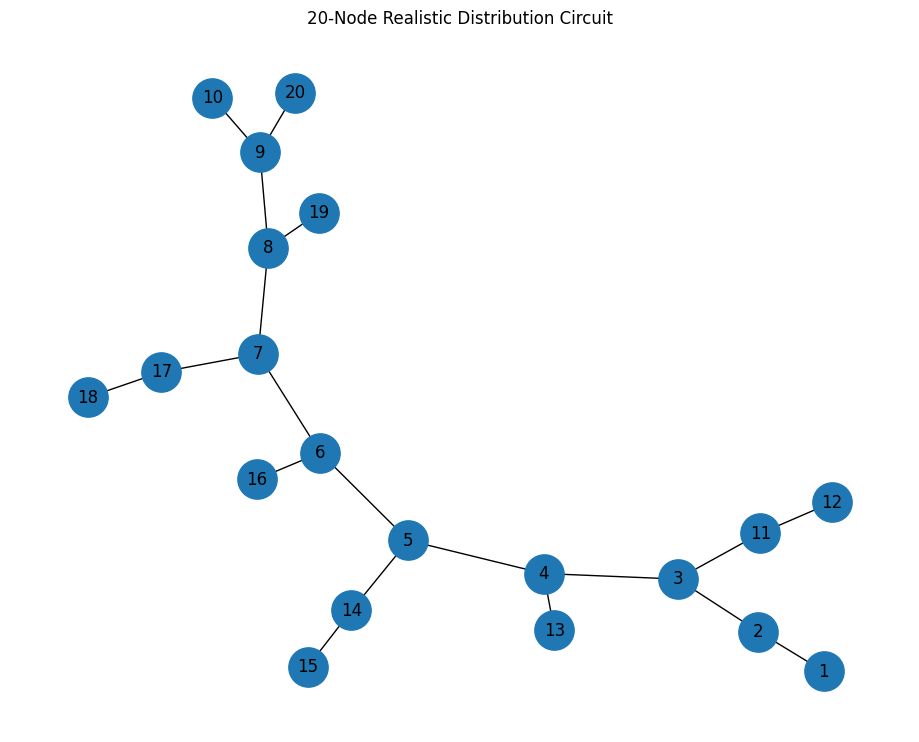

In [ ]:
plt.figure(figsize=(9,7))
pos = nx.spring_layout(G, seed=25)
nx.draw(G, pos, with_labels=True, node_size=800)
plt.title("20-Node Realistic Distribution Circuit")
plt.show()

In [ ]:
substation = 1
V_normal = {}

for node in G.nodes():
    distance = nx.shortest_path_length(G, substation, node)
    V_normal[node] = 1.0 - 0.008 * distance  # realistic voltage drop

V_normal

{1: 1.0,
 2: 0.992,
 3: 0.984,
 4: 0.976,
 5: 0.968,
 6: 0.96,
 7: 0.952,
 8: 0.944,
 9: 0.9359999999999999,
 10: 0.9279999999999999,
 11: 0.976,
 12: 0.968,
 13: 0.968,
 14: 0.96,
 15: 0.952,
 16: 0.952,
 17: 0.944,
 18: 0.9359999999999999,
 19: 0.9359999999999999,
 20: 0.9279999999999999}

In [ ]:
fault_node = 6
V_fault = {}

for node in G.nodes():
    d = nx.shortest_path_length(G, fault_node, node)

    if d == 0:
        V_fault[node] = V_normal[node] * 0.45   # severe sag
    elif d == 1:
        V_fault[node] = V_normal[node] * 0.65
    elif d == 2:
        V_fault[node] = V_normal[node] * 0.80
    elif d == 3:
        V_fault[node] = V_normal[node] * 0.90
    else:
        V_fault[node] = V_normal[node] * 0.98


In [ ]:
delta_V = {}

for node in G.nodes():
    delta_V[node] = (V_fault[node] - V_normal[node]) / V_normal[node]

delta_V

{1: -0.020000000000000018,
 2: -0.01999999999999997,
 3: -0.09999999999999994,
 4: -0.19999999999999993,
 5: -0.35,
 6: -0.55,
 7: -0.35,
 8: -0.19999999999999998,
 9: -0.10000000000000002,
 10: -0.020000000000000025,
 11: -0.019999999999999983,
 12: -0.020000000000000046,
 13: -0.1,
 14: -0.19999999999999996,
 15: -0.09999999999999995,
 16: -0.35,
 17: -0.19999999999999998,
 18: -0.10000000000000002,
 19: -0.10000000000000002,
 20: -0.020000000000000025}

In [ ]:
impact_level = {}

for node, dv in delta_V.items():
    if abs(dv) > 0.40:
        impact_level[node] = "High"
    elif abs(dv) > 0.20:
        impact_level[node] = "Medium"
    else:
        impact_level[node] = "Low"

impact_level

{1: 'Low',
 2: 'Low',
 3: 'Low',
 4: 'Low',
 5: 'Medium',
 6: 'High',
 7: 'Medium',
 8: 'Low',
 9: 'Low',
 10: 'Low',
 11: 'Low',
 12: 'Low',
 13: 'Low',
 14: 'Low',
 15: 'Low',
 16: 'Medium',
 17: 'Low',
 18: 'Low',
 19: 'Low',
 20: 'Low'}

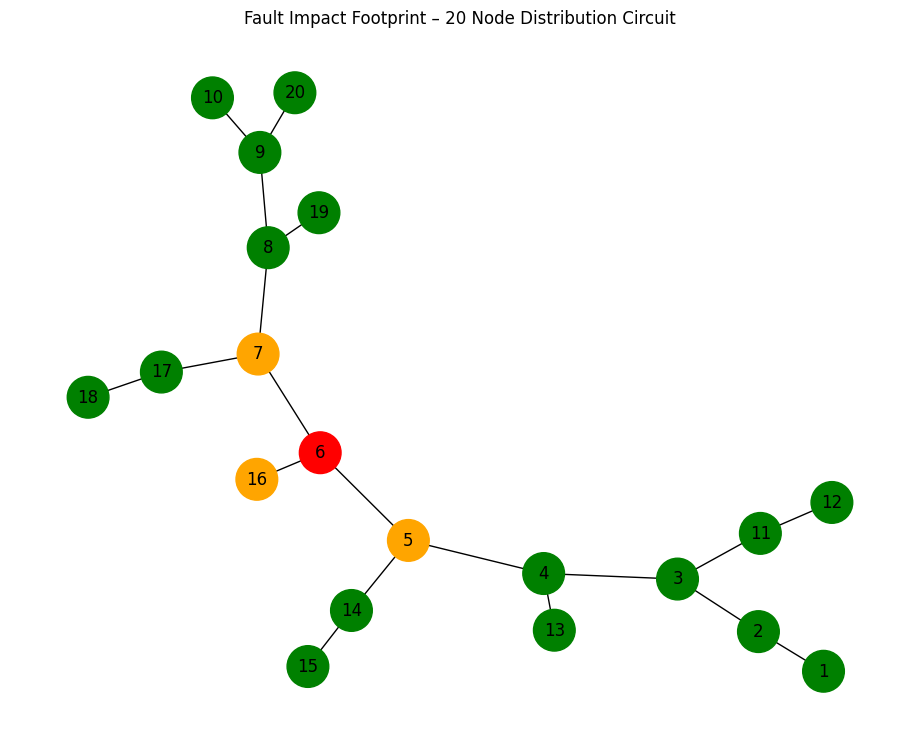

In [ ]:
colors = []
for node in G.nodes():
    if impact_level[node] == "High":
        colors.append("red")
    elif impact_level[node] == "Medium":
        colors.append("orange")
    else:
        colors.append("green")

plt.figure(figsize=(9,7))
nx.draw(G, pos, node_color=colors, with_labels=True, node_size=900)
plt.title("Fault Impact Footprint – 20 Node Distribution Circuit")
plt.show()


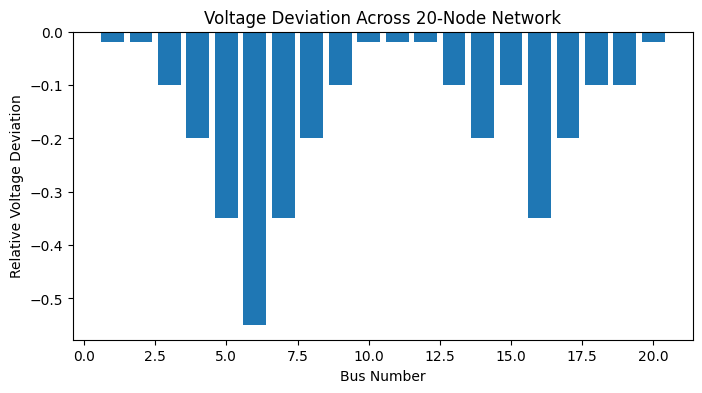

In [ ]:
plt.figure(figsize=(8,4))
plt.bar(delta_V.keys(), delta_V.values())
plt.xlabel("Bus Number")
plt.ylabel("Relative Voltage Deviation")
plt.title("Voltage Deviation Across 20-Node Network")
plt.show()